# Scrapping Indicators Data

In [ ]:
pip install -r requirements.txt

## Reporteros Sin Fronteras (RSF - Reporters Without Borders) 

In [11]:
import requests
import pandas as pd
import os
from io import StringIO  # Import StringIO

# URL to fetch the request table from
url = "https://rsf.org/en/index?year="

# List of years to iterate over
years = [str(year) for year in range(2002, 2024) if year != 2011]

# Function to get the request table from a given URL
def get_request_table(year):
    year_url = f"{url}{year}"
    response = requests.get(year_url)
    response.raise_for_status()  # Raise an error for bad responses
    
    # Use StringIO to convert the response text to a file-like object
    html_content = StringIO(response.text)
    
    # Get the first table on the page and return it as a DataFrame
    return pd.read_html(html_content)[0]

# Create a DataFrame to hold all the tables for the years
all_data = pd.DataFrame()

# Loop through the years and fetch the tables
for year in years:
    try:
        data = get_request_table(year)
        data['Year'] = year  # Add the year as a column to the data
        all_data = pd.concat([all_data, data], ignore_index=True)
    except Exception as e:
        print(f"Could not retrieve data for {year}: {e}")

# Clean the DataFrame
# 1. Keep only the necessary columns (Country, Year, Global score)
clean_data = all_data[['Countries', 'Year', 'Global score']].copy()

# 2. Rename columns for consistency
clean_data.columns = ['country', 'year', 'wpf_score']

# 3. Normalize the 'wpf_score' to values between 0 and 1
clean_data['wpf_score'] = (clean_data['wpf_score'] - clean_data['wpf_score'].min()) / (clean_data['wpf_score'].max() - clean_data['wpf_score'].min())

# Specify the directory where the CSV should be saved
save_dir = '../data/processed/3_indicators'

# Make sure the directory exists, if not create it
os.makedirs(save_dir, exist_ok=True)

# Save the cleaned data to a CSV file
csv_filename = os.path.join(save_dir, 'wpf_scores.csv')
clean_data.to_csv(csv_filename, index=False)

print(f"Data saved to {csv_filename}")


Data saved to ../data/processed/3_indicators/wpf_scores.csv


# Preparing data

In [279]:
# Existing imports and path setup...
import pandas as pd
import json
import os

In [280]:
# Paths
raw_data_path = "../data/raw"
polarisation_path = "../data/reports/polarisation_scores/"
wpf_path = "../data/processed/3_indicators"
output_path = "../data/processed/3_indicators"
os.makedirs(output_path, exist_ok=True)

In [281]:
# === ACLED EVENTS & FATALITIES ===

# Load ISO mapping
with open("iso_country.json") as f:
    iso_mapping = json.load(f)
iso_df = pd.DataFrame.from_dict(iso_mapping, orient='index').reset_index()
iso_df.columns = ['iso_code', 'country']


# ===== Load ACLED data =====

# Read "results" sheet from the Excel file
conflict = pd.read_excel(os.path.join(raw_data_path, "acled_2024_conflict_ranking.xlsx"), sheet_name="Results")

# Rename columns to match
conflict = conflict.rename(columns={"Country": "country", "Index Ranking December 2024": "conflict_ranking"})

# Merge with ISO mapping based on country names
conflict = conflict.merge(iso_df, on="country", how="left")

# Add year (assuming same year for all rows; change if dynamic)
conflict["year"] = 2024

# Reorder columns so that iso_code is right after country

cols = conflict.columns.tolist()
cols.remove("iso_code")
cols.insert(cols.index("country") + 1, "iso_code")
conflict = conflict[cols]

### Keep only relevant columns "country", "iso_code", "year", "conflict_ranking"
conflict = conflict[["country", "iso_code", "year", "conflict_ranking"]]

### Drop rows with missing ISO codes
conflict = conflict.dropna(subset=["iso_code"])

# === E-GOV DATA ===

egov = pd.read_csv(os.path.join(raw_data_path, "egov_un_data.csv"))
egov = egov.rename(columns={
    "Country Name": "country",
    "E-Participation Index": "e_participation_index",
    "Survey Year": "year"
})

# Keep only relevant columns
egov = egov[["country", "e_participation_index", "year"]]

# Clean country names before merging
egov["country"] = (
    egov["country"]
    .str.strip()
    .str.replace('"', '')
    .str.replace(r'\s+', ' ', regex=True)
)

# Manual corrections
manual_corrections = {
    "Iran (Islamic Republic of)": "Iran",
    "Viet Nam": "Vietnam",
    "Türkiye": "Turkey",
    "United States of America": "United States",
    "Russian Federation": "Russia",
    "Republic of Korea": "South Korea",
}
egov["country"] = egov["country"].replace(manual_corrections)

# Now merge after cleaning
egov = egov.merge(iso_df, on="country", how="left")

# Reorder columns so that iso_code is right after country
cols = egov.columns.tolist()
cols.remove("iso_code")
cols.insert(cols.index("country") + 1, "iso_code")
egov = egov[cols]

# === FREEDOM ON THE NET DATA ===
freedom = pd.read_excel(
    os.path.join(raw_data_path, "freedom_net_country_score_data.xlsx"),
    skiprows=1,
    engine="openpyxl"  # Make sure openpyxl is installed
)
freedom = freedom.rename(columns={
    "Country": "country",
    "Edition": "year",
    "Total": "media_freedom_score"
})
freedom = freedom[["country", "year", "media_freedom_score"]]
freedom = freedom.merge(iso_df, on="country", how="left")
freedom = freedom.dropna(subset=["iso_code"])

# Reorder columns so that iso_code is right after country
cols = freedom.columns.tolist()
cols.remove("iso_code")
cols.insert(cols.index("country") + 1, "iso_code")
freedom = freedom[cols]

# === POLARISATION SCORES ===
polarisation = pd.read_csv(os.path.join(polarisation_path, "merged_polarization_scores.csv"))

# Clean column names
polarisation = polarisation.rename(columns={"country": "iso_code"})
polarisation = polarisation.rename(columns={"country_full": "country"})

# Move 'country' to the first column
cols = ['country'] + [col for col in polarisation.columns if col != 'country']
polarisation = polarisation[cols]

# === 🆕 WPF SCORES ===

wpf = pd.read_csv(os.path.join(wpf_path, "wpf_scores.csv"))

# Manual corrections
manual_corrections = {
    "Türkiye": "Turkey",
    "Morocco / Western Sahara": "Morocco",
}
wpf["country"] = wpf["country"].replace(manual_corrections)

# Merge ISO codes using the iso_df mapping
wpf = wpf.merge(iso_df, on="country", how="left")

# Drop rows with missing ISO codes
wpf = wpf.dropna(subset=["iso_code"])

# Reorder columns so that iso_code is right after country
cols = wpf.columns.tolist()
cols.remove("iso_code")
cols.insert(cols.index("country") + 1, "iso_code")
wpf = wpf[cols]

# === Tertiary Enrollment Education ===

education = pd.read_csv(os.path.join(raw_data_path, "tertiary_enrollment_wb.csv"))

# Clean column names
education = education.rename(columns={"Country Name": "country", "Country Code": "iso_code"})

# Manual corrections
manual_corrections = {
    "Iran, Islamic Rep.": "Iran",
    "Viet Nam": "Vietnam",
    "Turkiye": "Turkey",
    "United States of America": "United States",
    "Russian Federation": "Russia",
    "Korea, Rep.": "South Korea",
    "Kyrgyz Republic" : "Kyrgyzstan",
    "Hong Kong SAR, China": "Hong Kong",
    "Egypt, Arab Rep.": "Egypt",
}
education["country"] = education["country"].replace(manual_corrections)

# Drop unused columns
education = education.drop(columns=["Series Name", "Series Code"])

# Melt the DataFrame to long format
education = education.melt(
    id_vars=["country", "iso_code"],
    var_name="year",
    value_name="enrollment_percentage"
)

# Clean up the year column: extract only the year (e.g., from "2020 [YR2020]" to 2020)
education["year"] = education["year"].str.extract(r'(\d{4})').astype("Int64")

# Create a list of valid country names from the values of the JSON
valid_countries = list(iso_mapping.values())

# Filter to only include countries in the ISO mapping
education = education[education["country"].isin(valid_countries)]

# Final column order (optional but clean)
education = education[["country", "iso_code", "year", "enrollment_percentage"]]

# Clean enrollment_percentage early
education["enrollment_percentage"] = (
    pd.to_numeric(education["enrollment_percentage"], errors="coerce")
)

# === Democracy Index ===

democracy = pd.read_csv(os.path.join(raw_data_path, "democracy_index_eiu.csv"))

# Clean column names
democracy = democracy.rename(columns={"Entity": "country", "Code": "iso_code", "Year": "year", "Democracy score": "democracy_score"})

# Drop iso codes not in ISO mapping
democracy = democracy[democracy["iso_code"].isin(iso_df["iso_code"])]

# === Population Size ===


# === FINAL MERGE ===
df = pd.merge(conflict, egov, on=["country", "iso_code", "year"], how="outer")
df = pd.merge(df, freedom, on=["country", "iso_code", "year"], how="outer")
df = pd.merge(df, polarisation, on=["country", "iso_code", "year"], how="outer")
df = pd.merge(df, wpf, on=["country", "iso_code", "year"], how="outer")  
df = pd.merge(df, education, on=["country", "iso_code", "year"], how="outer")
df = pd.merge(df, democracy, on=["country", "iso_code", "year"], how="outer")

# Reorder columns: put 'iso_code' and 'year' together, followed by other columns
columns_order = ['country', 'iso_code', 'year'] + [col for col in df.columns if col not in ['country', 'iso_code', 'year']]
df = df[columns_order]

# drop columns mean, ci_low, ci_high
df = df.drop(columns=["mean", "ci_low", "ci_high", "polarization_zscore"], errors='ignore')

# drop waves 4 and 5
df = df[~df['wave'].isin([4, 5])]

# === SAVE OUTPUT ===
output_file = os.path.join(output_path, "misinformation_vulnerability_risk_index.csv")
df.to_csv(output_file, index=False)


## Building the Misinformation Vulnerability Index

In [282]:
# Load the misinformation index data
df = pd.read_csv("../data/processed/3_indicators/misinformation_vulnerability_risk_index.csv")

In [283]:
### === Misinformation Index ===

# Load the misinformation index data
df = pd.read_csv("../data/processed/3_indicators/misinformation_vulnerability_risk_index.csv")

# Variables we want to keep the most recent values for
target_vars = [
    "conflict_ranking", "e_participation_index", "media_freedom_score",
    "wave", "polarization_score", "wpf_score",
    "enrollment_percentage", "democracy_score"
]

# This function will return the most recent non-null value for a column
def get_latest_value(group, column):
    non_null_values = group.dropna(subset=[column])
    if non_null_values.empty:
        return pd.NA
    else:
        return non_null_values.sort_values("year", ascending=False).iloc[0][column]
    
# Build the result
rows = []
for country, group in df.groupby("country"):
    row = {
        "country": country,
        "iso_code": group["iso_code"].iloc[0]  # Assuming iso_code is constant per country
    }
    for col in target_vars:
        row[col] = get_latest_value(group, col)
    rows.append(row)

# Final DataFrame
result_df = pd.DataFrame(rows)

# Delete wave column
result_df = result_df.drop(columns=["wave"], errors='ignore')

# ======= Bye HKG Territory and Taiwan ==========

# Remove Hong Kong and Taiwan rows
result_df = result_df[result_df["country"] != "Hong Kong"]
#result_df = result_df[result_df["country"] != "Taiwan"]

### Save as 'clean_misinformation_features.csv' in the reports, misinformation_indes directory
save_dir = '../data/reports/misinformation_index'
os.makedirs(save_dir, exist_ok=True)
result_df.to_csv(os.path.join(save_dir, "clean_misinformation_features.csv"), index=False)

# Check shape
print(result_df.shape)  # Should be (43, 15)

(42, 9)


# Standarizing Data

## Normalization

In [291]:
import pandas as pd

# Load your data
df = pd.read_csv("../data/reports/misinformation_index/clean_misinformation_features.csv")

# Step 1: Convert relevant columns to float
numeric_columns = [
    'conflict_ranking',
    'e_participation_index',
    'media_freedom_score',
    'polarization_score',
    'wpf_score',
    'enrollment_percentage',
    'democracy_score'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Step 2: Reverse where needed
columns_to_reverse = ['conflict_ranking', 'e_participation_index', 'enrollment_percentage', 'democracy_score']
reversed_columns = []

for col in columns_to_reverse:
    reversed_col = f'{col}_rev'
    df[reversed_col] = df[col].max(skipna=True) - df[col]
    reversed_columns.append(reversed_col)

# Step 3: Normalize each column (original or reversed)
columns_to_normalize = {
    'conflict_ranking': 'conflict_ranking_rev',
    'e_participation_index': 'e_participation_index',
    'media_freedom_score': 'media_freedom_score',
    'polarization_score': 'polarization_score',
    'wpf_score': 'wpf_score',
    'enrollment_percentage': 'enrollment_percentage',
    'democracy_score': 'democracy_score'
}

normalized_columns = []

for name, col in columns_to_normalize.items():
    norm_col = f'{name}_norm'
    min_val = df[col].min(skipna=True)
    max_val = df[col].max(skipna=True)

    # Avoid divide-by-zero
    if min_val == max_val:
        df[norm_col] = 0.0
       
    else:
        df[norm_col] = (df[col] - min_val) / (max_val - min_val)

    normalized_columns.append(norm_col)

# Step 4: Preview results
cols_to_show = ['country', 'iso_code'] + numeric_columns + reversed_columns + normalized_columns
final_df = df[cols_to_show]

# Create a new DataFrame with only the normalized columns
norm_cols = [col for col in final_df.columns if col.endswith('_norm')]

# Include 'country' and 'iso_code' along with the normalized columns
final_df_norm = final_df[['country', 'iso_code'] + norm_cols]

# Print column names
print("Normalized columns:")
print(final_df_norm.columns.tolist())

Normalized columns:
['country', 'iso_code', 'conflict_ranking_norm', 'e_participation_index_norm', 'media_freedom_score_norm', 'polarization_score_norm', 'wpf_score_norm', 'enrollment_percentage_norm', 'democracy_score_norm']


### Check for missing values

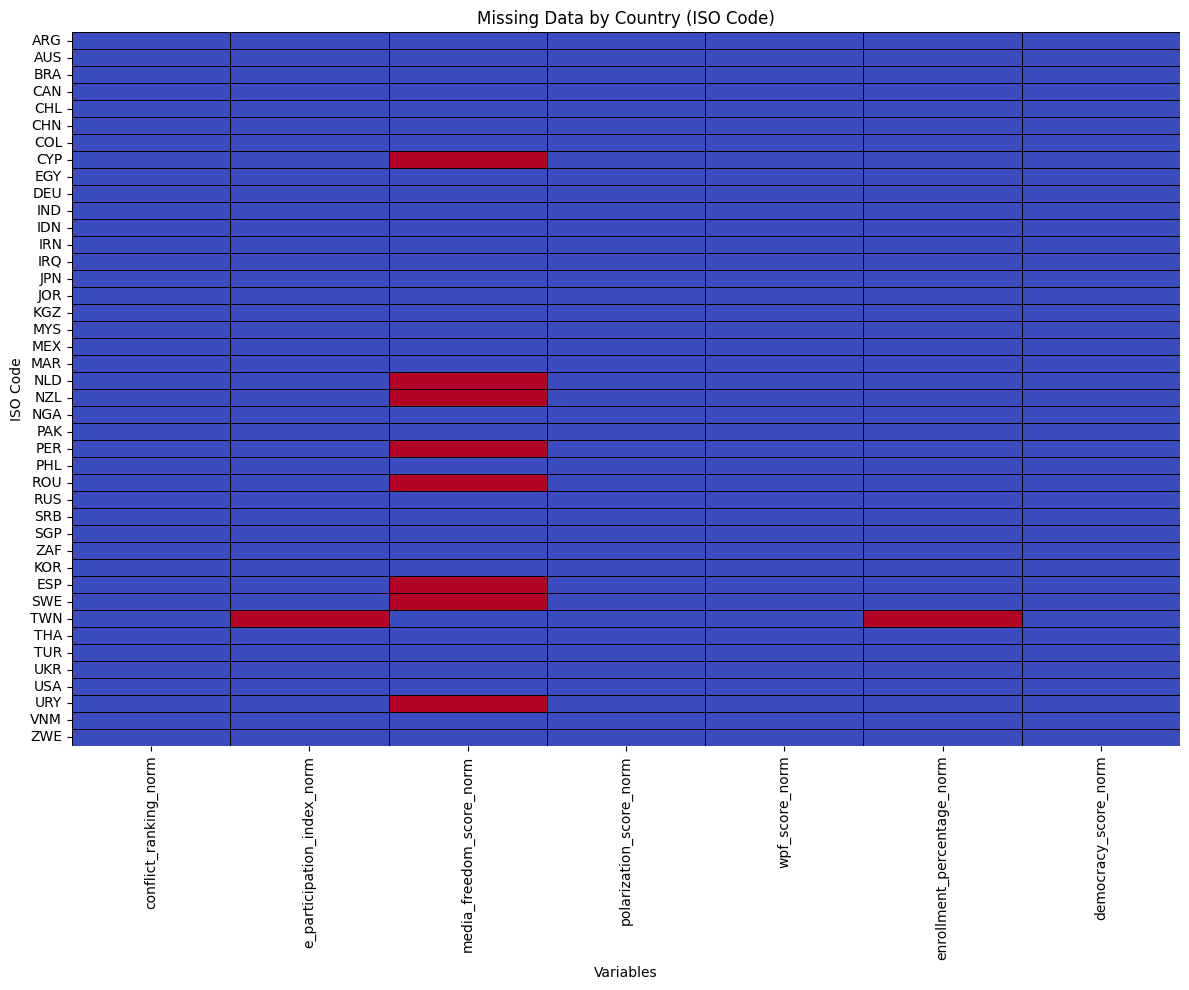

In [292]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define target variables
target_vars = [
    "conflict_ranking_norm", "e_participation_index_norm", "media_freedom_score_norm",
    "polarization_score_norm", "wpf_score_norm",
    "enrollment_percentage_norm", "democracy_score_norm"
]

plot_vars = [var for var in target_vars if var in final_df_norm.columns]

# Select only the columns you care about
data_to_plot = final_df_norm.set_index("iso_code")[plot_vars]

# Plot missing data heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(data_to_plot.isna(), cbar=False, cmap="coolwarm", yticklabels=True, linewidths=0.5, linecolor='black')

plt.title("Missing Data by Country (ISO Code)")
plt.xlabel("Variables")
plt.ylabel("ISO Code")
plt.tight_layout()
plt.show()

# Dealing with Missing Values

In [293]:
### Adding the Region Column form the region_map.json file

# Load the region mapping from JSON (iso_code -> region)
with open("region_map.json", "r") as f:
    region_mapping = json.load(f)

# Convert to DataFrame: 'iso_code' as key, 'region' as value
region_df = pd.DataFrame(list(region_mapping.items()), columns=["iso_code", "region"])

# Merge based on 'iso_code'
final_df_norm = final_df_norm.merge(region_df, on="iso_code", how="left")

# Reorder columns: place 'region' right after 'iso_code'
cols = final_df_norm.columns.tolist()
if "region" in cols:
    cols.remove("region")
    insert_at = cols.index("iso_code") + 1
    cols.insert(insert_at, "region")
    final_df_norm = final_df_norm[cols]

# Preview the result
print(final_df_norm.columns)

Index(['country', 'iso_code', 'region', 'conflict_ranking_norm',
       'e_participation_index_norm', 'media_freedom_score_norm',
       'polarization_score_norm', 'wpf_score_norm',
       'enrollment_percentage_norm', 'democracy_score_norm'],
      dtype='object')


# Imputing Missing Values

## A) Using Artificial Data from Regional Means

In [300]:
# List of columns to impute
cols_to_impute = [
    "e_participation_index_norm",
    "media_freedom_score_norm",
    "enrollment_percentage_norm"
]

# Impute missing values with the regional mean
for col in cols_to_impute:
    final_df_norm[col] = final_df_norm.groupby("region")[col].transform(
        lambda x: x.fillna(x.mean())
    )

# Optional: check if any values are still missing
missing_check = final_df_norm[cols_to_impute].isnull().sum()
print("🧼 Remaining missing values (should be 0 if regions are complete):")
print(missing_check)

🧼 Remaining missing values (should be 0 if regions are complete):
e_participation_index_norm    0
media_freedom_score_norm      0
enrollment_percentage_norm    0
dtype: int64


# Correlations

### Correlation Matrix

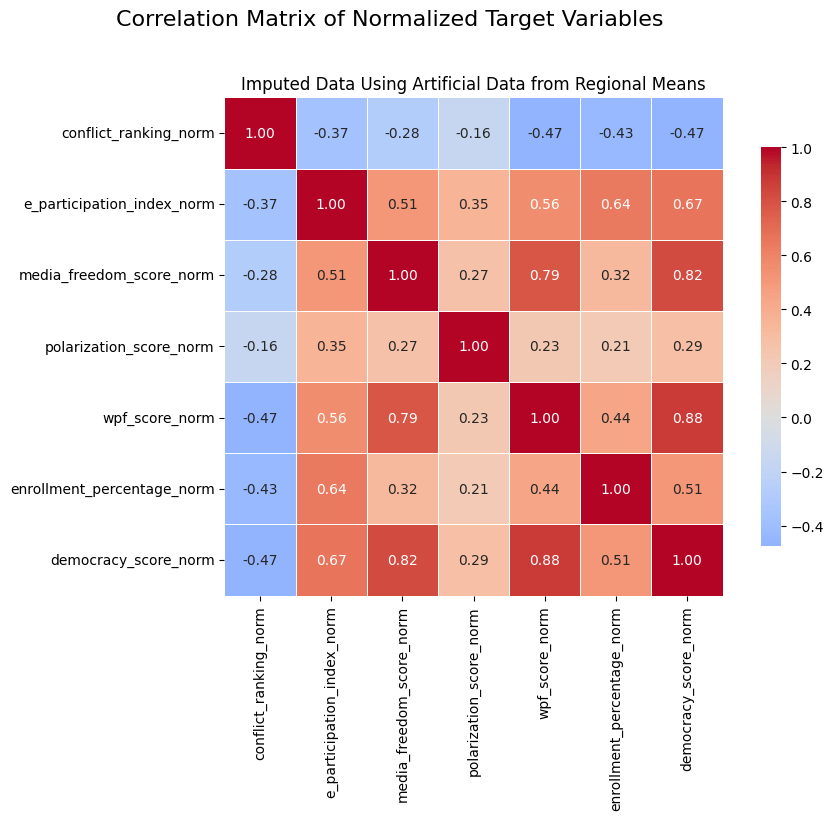

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Define the target variables
target_vars = [
    "conflict_ranking_norm", "e_participation_index_norm", "media_freedom_score_norm",
    "polarization_score_norm", "wpf_score_norm",
    "enrollment_percentage_norm", "democracy_score_norm"
]

# Make sure the columns are numeric and drop rows with any missing values in these columns
df_corr = final_df_norm[target_vars].apply(pd.to_numeric, errors='coerce').dropna()

# Compute the correlation matrix
correlation_matrix = df_corr.corr()

# Display the correlation matrix as a heatmap with subtitle
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    fmt=".2f",
    cbar_kws={"shrink": 0.8}
)

# Add title and subtitle
plt.suptitle("Correlation Matrix of Normalized Target Variables", fontsize=16, y=1.02)
plt.title("Imputed Values Using Artificial Data from Regional Means", fontsize=12)

plt.tight_layout()
plt.show()

## B) Weighting With Available Indicators